# LSTM Deep Learning - Rossmann Sales Forecasting

**Author:** Mulusew M. Tesfaye  
**ID:** a25multe  
**Date:** 2025-11-18



I was able to implement an LSTM neural network to forecast daily sales 6 weeks ahead and compare it with previous ML models. The focus was on:

Capturing temporal patterns and long-term dependencies in sales

Efficient data handling with sequence creation, batching, and float32 precision

Fast, memory-friendly training using top stores, lightweight 2-layer architecture, GPU when available, and early stopping

Evaluating performance against ML baselines and analyzing time series characteristics

LSTM was chosen because it naturally handles sequential data, non-linear patterns, and multi-step forecasts better than traditional ML models.

In [2]:
# Import required libraries
import sys
import platform
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import logging
import joblib
import gc
import time
from datetime import datetime
from typing import Generator, Tuple
import psutil
import os

# Deep Learning Framework
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.optimizers.legacy import Adam as LegacyAdam  # For M1/M2 Mac compatibility
    USE_TENSORFLOW = True
    print("✓ TensorFlow imported successfully")
except ImportError:
    USE_TENSORFLOW = False
    print("⚠ TensorFlow not available. Install with: pip install tensorflow")

# Time Series Analysis
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Scikit-learn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Visualization settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
if USE_TENSORFLOW:
    tf.random.set_seed(RANDOM_STATE)

# Setup paths
project_root = Path.cwd().parent
data_dir = project_root / 'data'
processed_dir = data_dir / 'processed'
models_dir = project_root / 'models'
logs_dir = project_root / 'logs'
reports_dir = project_root / 'reports'

# Create directories if they don't exist
models_dir.mkdir(exist_ok=True)
logs_dir.mkdir(exist_ok=True)
reports_dir.mkdir(exist_ok=True)

# Setup logging
log_file = logs_dir / f"lstm_training_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler(log_file),
        logging.StreamHandler()
    ]
)

print("✓ Libraries imported successfully")
print(f"✓ Logging initialized: {log_file}")

✓ TensorFlow imported successfully
✓ Libraries imported successfully
✓ Logging initialized: /Users/mulsewsmba/Desktop/rossmann-sales-forecasting/logs/lstm_training_20251208_140623.log


## 1. System Configuration & Hardware Detection


In [3]:
# System Information
print("="*60)
print("SYSTEM INFORMATION")
print("="*60)
print(f"Python version: {sys.version}")
print(f"Platform: {platform.platform()}")

# GPU Detection (TensorFlow)
if USE_TENSORFLOW:
    gpus = tf.config.list_physical_devices('GPU')
    print(f"\nTensorFlow GPUs Available: {len(gpus)}")
    if gpus:
        try:
            # Enable memory growth to avoid allocating all GPU memory
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
            print("GPU memory growth enabled")
            for i, gpu in enumerate(gpus):
                print(f"  GPU {i}: {gpu}")
        except RuntimeError as e:
            print(f"GPU configuration error: {e}")
    else:
        print("No GPUs detected - using CPU")
    
    print(f"\nTensorFlow version: {tf.__version__}")
    print(f"Using device: {tf.test.gpu_device_name() if tf.test.is_gpu_available() else 'CPU'}")

print("="*60)


SYSTEM INFORMATION
Python version: 3.11.0 | packaged by conda-forge | (main, Jan 14 2023, 12:25:12) [Clang 14.0.6 ]
Platform: macOS-26.1-arm64-arm-64bit

TensorFlow GPUs Available: 0
No GPUs detected - using CPU

TensorFlow version: 2.13.0
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


2025-12-08 14:06:33,247 - WARNING - From /var/folders/5k/spsmltbj1jg0m87zn5zdbd1r0000gn/T/ipykernel_50436/1869500205.py:26: is_gpu_available (from tensorflow.python.framework.test_util) is deprecated and will be removed in a future version.
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


Using device: CPU


## 2. System Resource Monitoring


In [4]:
def get_memory_usage():
    """Get current process memory usage in MB"""
    process = psutil.Process(os.getpid())
    mem_mb = process.memory_info().rss / 1024 / 1024
    return mem_mb

def get_available_memory():
    """Get available system memory in MB"""
    mem = psutil.virtual_memory()
    return mem.available / 1024 / 1024

def log_memory_usage(stage):
    """Log memory usage at different stages"""
    used = get_memory_usage()
    available = get_available_memory()
    print(f"[{stage}] Memory used: {used:.2f} MB | Available: {available:.2f} MB")
    logging.info(f"[{stage}] Memory used: {used:.2f} MB | Available: {available:.2f} MB")

# Monitor at start
log_memory_usage("Notebook Start")


2025-12-08 14:06:36,801 - INFO - [Notebook Start] Memory used: 75.47 MB | Available: 1129.42 MB


[Notebook Start] Memory used: 75.47 MB | Available: 1129.42 MB


## 3. Efficient Data Loading


In [5]:
# Check file size first
file_path = processed_dir / 'train_processed.csv'
file_size_mb = os.path.getsize(file_path) / (1024 * 1024)
print(f"File size: {file_size_mb:.2f} MB")

log_memory_usage("Before data load")

# Load feature importance to select top features
feature_importance_path = processed_dir / 'feature_importance.csv'
if feature_importance_path.exists():
    feature_importance = pd.read_csv(feature_importance_path)
    # Select top 15 most important features
    top_features = feature_importance.head(15)['feature'].tolist()
    print(f"\nSelected top {len(top_features)} features based on importance")
else:
    # Fallback: use all numeric features
    print("Feature importance file not found, will use all numeric features")
    top_features = None

# Load only necessary columns
if top_features:
    # Ensure we have essential columns
    needed_cols = ['Date', 'Store', 'Sales'] + [f for f in top_features if f in pd.read_csv(file_path, nrows=1).columns]
else:
    # Load sample to get column names
    sample = pd.read_csv(file_path, nrows=1000)
    numeric_cols = sample.select_dtypes(include=[np.number]).columns.tolist()
    needed_cols = ['Date', 'Store', 'Sales'] + [col for col in numeric_cols if col not in ['Date', 'Store', 'Sales']][:15]

print(f"Loading {len(needed_cols)} columns...")

# For large files, use chunked reading
if file_size_mb > 500:
    print("Using chunked reading for large file...")
    chunks = pd.read_csv(file_path, 
                        chunksize=100000,
                        usecols=needed_cols,
                        dtype={'Sales': 'float32'})
    
    # First pass: get top stores by total sales
    print("Identifying top stores by sales...")
    store_sales = {}
    for chunk in chunks:
        store_sales_chunk = chunk.groupby('Store')['Sales'].sum()
        for store, sales in store_sales_chunk.items():
            store_sales[store] = store_sales.get(store, 0) + sales
    
    # Select top 100 stores
    selected_stores = sorted(store_sales.items(), key=lambda x: x[1], reverse=True)[:100]
    selected_stores = [store for store, _ in selected_stores]
    
    # Second pass: load only selected stores
    chunks = pd.read_csv(file_path, 
                        chunksize=100000,
                        usecols=needed_cols,
                        dtype={'Sales': 'float32'})
    
    sampled_data = pd.concat([chunk[chunk['Store'].isin(selected_stores)] 
                             for chunk in chunks])
    del chunks
else:
    # Load all at once if file is small
    sampled_data = pd.read_csv(file_path, 
                              usecols=needed_cols,
                              dtype={'Sales': 'float32'})
    # Sample stores
    store_sales = sampled_data.groupby('Store')['Sales'].sum().sort_values(ascending=False)
    selected_stores = store_sales.head(100).index.tolist()
    sampled_data = sampled_data[sampled_data['Store'].isin(selected_stores)]

# Convert Date column
sampled_data['Date'] = pd.to_datetime(sampled_data['Date'])

print(f"\nData loaded successfully!")
print(f"  - Selected stores: {len(selected_stores)}")
print(f"  - Total samples: {len(sampled_data):,}")
print(f"  - Date range: {sampled_data['Date'].min()} to {sampled_data['Date'].max()}")
print(f"  - Features: {len(needed_cols) - 3}")  # Exclude Date, Store, Sales

log_memory_usage("After data load")

# Clean up
gc.collect()
log_memory_usage("After garbage collection")


2025-12-08 14:06:40,753 - INFO - [Before data load] Memory used: 63.16 MB | Available: 1142.31 MB


File size: 462.79 MB
[Before data load] Memory used: 63.16 MB | Available: 1142.31 MB

Selected top 15 features based on importance
Loading 18 columns...


2025-12-08 14:06:42,854 - INFO - [After data load] Memory used: 481.00 MB | Available: 1178.05 MB



Data loaded successfully!
  - Selected stores: 100
  - Total samples: 89,532
  - Date range: 2013-01-01 00:00:00 to 2015-06-18 00:00:00
  - Features: 15
[After data load] Memory used: 481.00 MB | Available: 1178.05 MB
[After garbage collection] Memory used: 664.34 MB | Available: 1261.59 MB


2025-12-08 14:06:43,079 - INFO - [After garbage collection] Memory used: 664.34 MB | Available: 1261.59 MB


## 4. Time Series Stationarity Check


Testing stationarity on sample stores...

Stationarity Test Results:
   adf_statistic   p_value is_stationary
25     -4.616559   0.00012          True
42     -5.105239  0.000014          True
57     -4.623628  0.000117          True
64     -4.063463  0.001112          True
84     -5.266533  0.000006          True


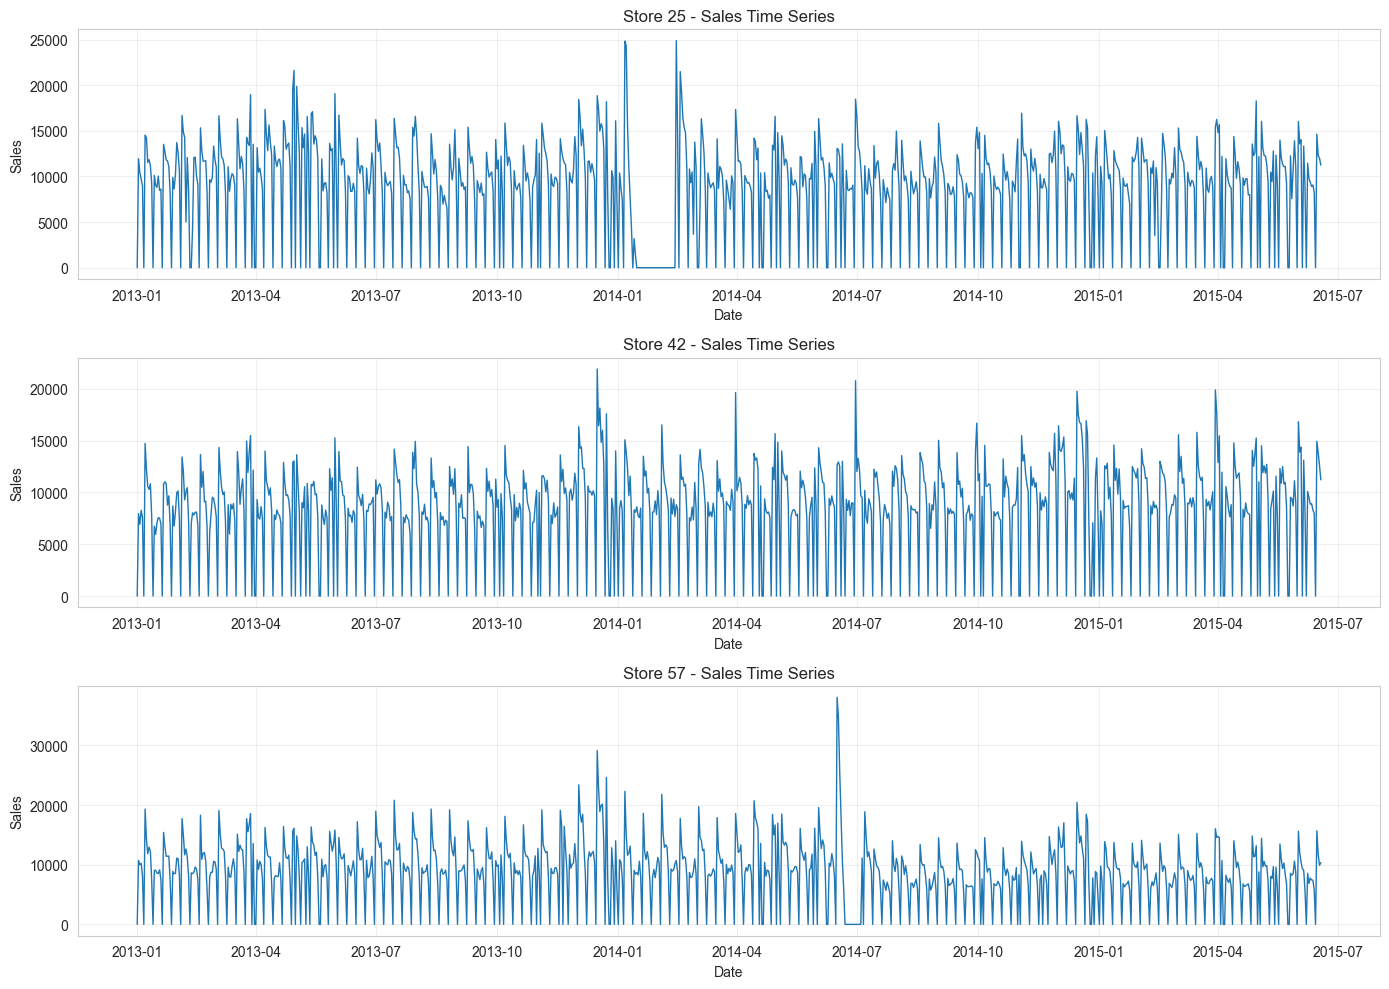

2025-12-08 14:06:48,167 - INFO - [After stationarity check] Memory used: 128.55 MB | Available: 1179.25 MB


[After stationarity check] Memory used: 128.55 MB | Available: 1179.25 MB


In [6]:
def check_stationarity_sample(data, n_stores=5):
    """Test stationarity on sample stores only"""
    sample_stores = data['Store'].unique()[:n_stores]
    results = {}
    
    for store in sample_stores:
        store_data = data[data['Store']==store].sort_values('Date')['Sales']
        store_data = store_data.dropna()
        
        if len(store_data) > 10:  # Need minimum data points
            adf_result = adfuller(store_data)
            results[store] = {
                'adf_statistic': adf_result[0],
                'p_value': adf_result[1],
                'is_stationary': adf_result[1] < 0.05
            }
    
    return pd.DataFrame(results).T

# Run test on sample stores
print("Testing stationarity on sample stores...")
stationarity_results = check_stationarity_sample(sampled_data, n_stores=5)
print("\nStationarity Test Results:")
print(stationarity_results)

# Visualize time series for sample stores
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
sample_stores = sampled_data['Store'].unique()[:3]

for idx, store in enumerate(sample_stores):
    store_data = sampled_data[sampled_data['Store']==store].sort_values('Date')
    axes[idx].plot(store_data['Date'], store_data['Sales'], linewidth=1)
    axes[idx].set_title(f'Store {store} - Sales Time Series')
    axes[idx].set_xlabel('Date')
    axes[idx].set_ylabel('Sales')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(reports_dir / 'time_series_sample_stores.png', dpi=100, bbox_inches='tight')
plt.show()
plt.close()

log_memory_usage("After stationarity check")


## 5. Autocorrelation Analysis


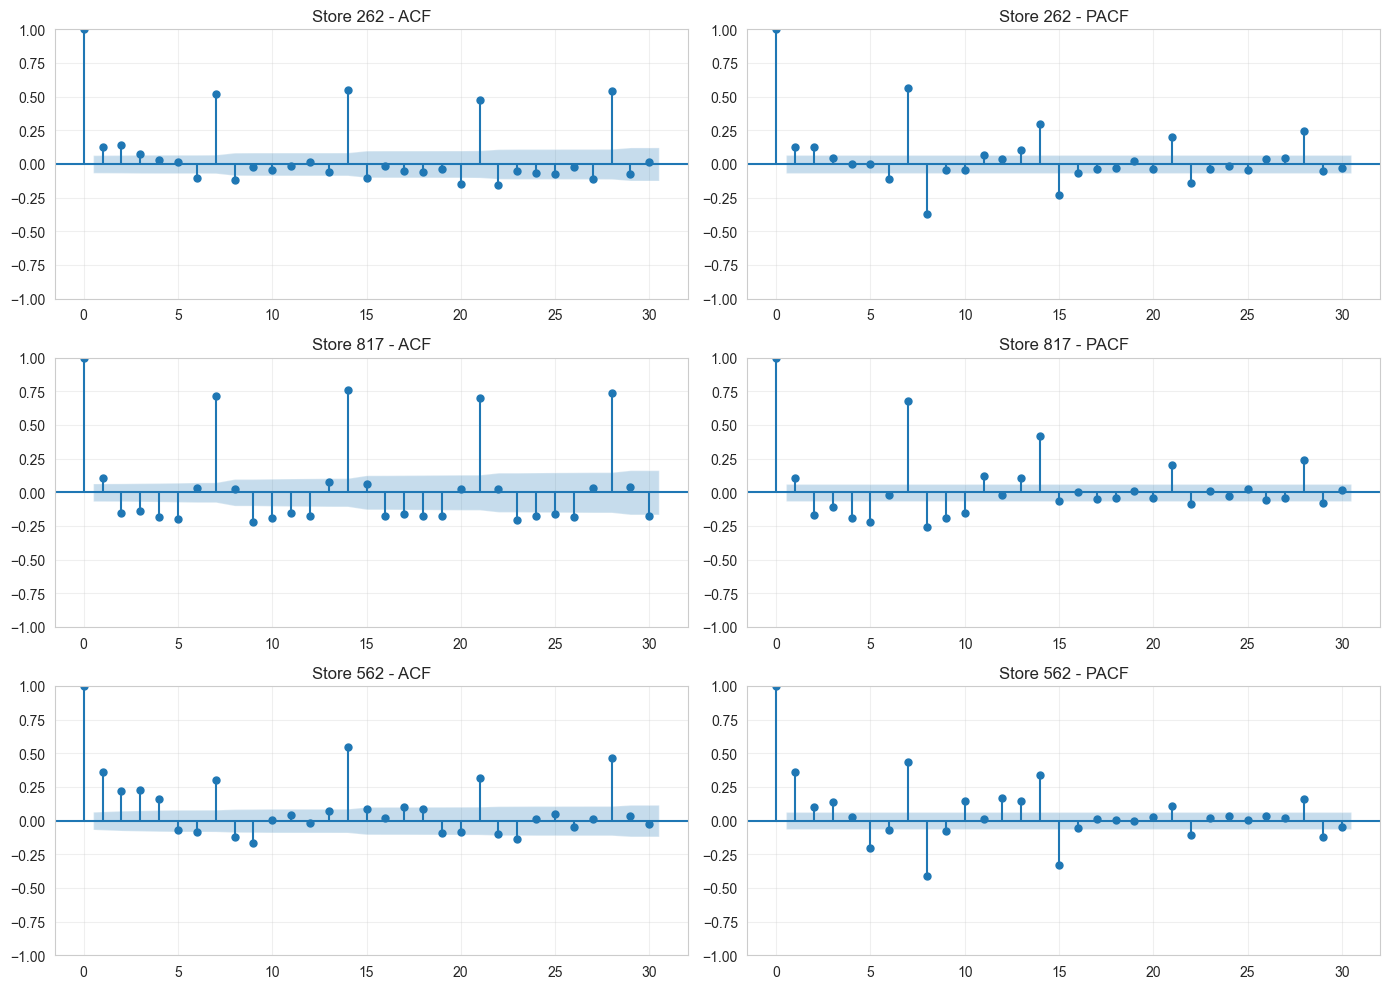

2025-12-08 14:06:56,883 - INFO - [After autocorrelation analysis] Memory used: 116.92 MB | Available: 1289.33 MB



Selected sequence parameters:
  - Lookback window: 7 days
  - Forecast horizon: 1 day(s)
[After autocorrelation analysis] Memory used: 116.92 MB | Available: 1289.33 MB


In [7]:
# Analyze only 3 stores to save memory
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

for idx, store in enumerate(selected_stores[:3]):
    store_data = sampled_data[sampled_data['Store']==store].sort_values('Date')['Sales'].dropna()
    
    if len(store_data) > 30:
        plot_acf(store_data, lags=30, ax=axes[idx, 0], alpha=0.05)
        axes[idx, 0].set_title(f'Store {store} - ACF')
        axes[idx, 0].grid(True, alpha=0.3)
        
        plot_pacf(store_data, lags=30, ax=axes[idx, 1], alpha=0.05)
        axes[idx, 1].set_title(f'Store {store} - PACF')
        axes[idx, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(reports_dir / 'acf_pacf_analysis.png', dpi=100, bbox_inches='tight')
plt.show()
plt.close()

# Determine optimal sequence length based on analysis
# Recommendation: Use 7-14 days lookback (not 30+) to save memory
LOOKBACK = 7  # Past 7 days
FORECAST_HORIZON = 1  # Predict next day

print(f"\nSelected sequence parameters:")
print(f"  - Lookback window: {LOOKBACK} days")
print(f"  - Forecast horizon: {FORECAST_HORIZON} day(s)")

log_memory_usage("After autocorrelation analysis")


## 6. Create Supervised Learning Data (Memory-Efficient)


In [8]:
def create_sequences_efficient(data, store_id, feature_cols, lookback=7, forecast_horizon=1):
    """
    Memory-efficient sequence creation for single store
    Returns numpy arrays, not generator (faster for training)
    """
    store_data = data[data['Store']==store_id].sort_values('Date')
    
    # Convert to numpy for speed
    sales = store_data['Sales'].values.astype('float32')
    features = store_data[feature_cols].values.astype('float32')
    
    n_sequences = len(sales) - lookback - forecast_horizon + 1
    
    if n_sequences <= 0:
        return None, None
    
    # Pre-allocate arrays (faster than appending)
    X = np.zeros((n_sequences, lookback, len(feature_cols)), dtype='float32')
    y = np.zeros((n_sequences, forecast_horizon), dtype='float32')
    
    for i in range(n_sequences):
        X[i] = features[i:i+lookback]
        y[i] = sales[i+lookback:i+lookback+forecast_horizon]
    
    return X, y

# Process stores in batches to manage memory
def create_dataset_batched(data, stores, feature_cols, lookback=7, batch_size=20):
    """
    Create dataset by processing stores in batches
    """
    X_list = []
    y_list = []
    
    for i in range(0, len(stores), batch_size):
        batch_stores = stores[i:i+batch_size]
        print(f"Processing stores {i} to {i+len(batch_stores)}...")
        
        for store in batch_stores:
            X_store, y_store = create_sequences_efficient(
                data, store, feature_cols, lookback
            )
            if X_store is not None:
                X_list.append(X_store)
                y_list.append(y_store)
        
        # Log memory after each batch
        log_memory_usage(f"Batch {i//batch_size + 1}")
    
    # Concatenate all sequences
    if X_list:
        X_all = np.concatenate(X_list, axis=0)
        y_all = np.concatenate(y_list, axis=0)
    else:
        X_all = np.array([])
        y_all = np.array([])
    
    # Clean up
    del X_list, y_list
    gc.collect()
    
    return X_all, y_all

print("Sequence creation functions defined")


Sequence creation functions defined


In [9]:
# Get feature columns (exclude Date, Store, Sales)
feature_cols = [col for col in sampled_data.columns 
                if col not in ['Date', 'Store', 'Sales']]

print(f"Feature columns: {len(feature_cols)}")
print(f"Features: {feature_cols[:10]}...")  # Show first 10

# Split data temporally (last 6 weeks for test)
test_weeks = 6
test_days = test_weeks * 7

train_data = sampled_data.groupby('Store').apply(
    lambda x: x.sort_values('Date').iloc[:-test_days] if len(x) > test_days else x.sort_values('Date').iloc[:int(len(x)*0.8)]
).reset_index(drop=True)

test_data = sampled_data.groupby('Store').apply(
    lambda x: x.sort_values('Date').iloc[-test_days:] if len(x) > test_days else x.sort_values('Date').iloc[int(len(x)*0.8):]
).reset_index(drop=True)

print(f"\nTrain date range: {train_data['Date'].min()} to {train_data['Date'].max()}")
print(f"Test date range: {test_data['Date'].min()} to {test_data['Date'].max()}")

# Create sequences
log_memory_usage("Before sequence creation")

print("\nCreating training sequences...")
X_train, y_train = create_dataset_batched(
    train_data, selected_stores, feature_cols, 
    lookback=LOOKBACK, batch_size=20
)

print("\nCreating test sequences...")
X_test, y_test = create_dataset_batched(
    test_data, selected_stores, feature_cols,
    lookback=LOOKBACK, batch_size=20
)

log_memory_usage("After sequence creation")

print(f"\nSequence shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  X_test: {X_test.shape}")
print(f"  y_test: {y_test.shape}")

# Clean up original dataframes if not needed
del train_data, test_data
gc.collect()


2025-12-08 14:07:06,044 - INFO - [Before sequence creation] Memory used: 144.00 MB | Available: 1277.50 MB
2025-12-08 14:07:06,064 - INFO - [Batch 1] Memory used: 145.91 MB | Available: 1273.92 MB
2025-12-08 14:07:06,083 - INFO - [Batch 2] Memory used: 146.66 MB | Available: 1273.92 MB
2025-12-08 14:07:06,102 - INFO - [Batch 3] Memory used: 149.75 MB | Available: 1273.92 MB
2025-12-08 14:07:06,120 - INFO - [Batch 4] Memory used: 154.31 MB | Available: 1273.92 MB
2025-12-08 14:07:06,139 - INFO - [Batch 5] Memory used: 154.81 MB | Available: 1273.92 MB


Feature columns: 15
Features: ['Sales_Lag1', 'Sales_Lag7', 'Sales_Lag14', 'Customers_Lag7', 'Sales_MA7', 'Sales_MA14', 'Sales_MA30', 'Sales_Std7', 'Sales_Std30', 'Sales_Max7']...

Train date range: 2013-01-01 00:00:00 to 2015-05-07 00:00:00
Test date range: 2015-05-08 00:00:00 to 2015-06-18 00:00:00
[Before sequence creation] Memory used: 144.00 MB | Available: 1277.50 MB

Creating training sequences...
Processing stores 0 to 20...
[Batch 1] Memory used: 145.91 MB | Available: 1273.92 MB
Processing stores 20 to 40...
[Batch 2] Memory used: 146.66 MB | Available: 1273.92 MB
Processing stores 40 to 60...
[Batch 3] Memory used: 149.75 MB | Available: 1273.92 MB
Processing stores 60 to 80...
[Batch 4] Memory used: 154.31 MB | Available: 1273.92 MB
Processing stores 80 to 100...
[Batch 5] Memory used: 154.81 MB | Available: 1273.92 MB


2025-12-08 14:07:06,354 - INFO - [Batch 1] Memory used: 414.34 MB | Available: 1273.92 MB
2025-12-08 14:07:06,361 - INFO - [Batch 2] Memory used: 413.59 MB | Available: 1273.92 MB
2025-12-08 14:07:06,369 - INFO - [Batch 3] Memory used: 409.42 MB | Available: 1273.92 MB
2025-12-08 14:07:06,376 - INFO - [Batch 4] Memory used: 409.42 MB | Available: 1273.92 MB
2025-12-08 14:07:06,383 - INFO - [Batch 5] Memory used: 409.42 MB | Available: 1273.92 MB
2025-12-08 14:07:06,480 - INFO - [After sequence creation] Memory used: 406.91 MB | Available: 1273.92 MB



Creating test sequences...
Processing stores 0 to 20...
[Batch 1] Memory used: 414.34 MB | Available: 1273.92 MB
Processing stores 20 to 40...
[Batch 2] Memory used: 413.59 MB | Available: 1273.92 MB
Processing stores 40 to 60...
[Batch 3] Memory used: 409.42 MB | Available: 1273.92 MB
Processing stores 60 to 80...
[Batch 4] Memory used: 409.42 MB | Available: 1273.92 MB
Processing stores 80 to 100...
[Batch 5] Memory used: 409.42 MB | Available: 1273.92 MB
[After sequence creation] Memory used: 406.91 MB | Available: 1273.92 MB

Sequence shapes:
  X_train: (84632, 7, 15)
  y_train: (84632, 1)
  X_test: (3500, 7, 15)
  y_test: (3500, 1)


0

In [10]:
# Data Quality Check - Validate for NaN/Inf before scaling
print("="*60)
print("DATA QUALITY VALIDATION")
print("="*60)

# Check training data
x_train_nan = np.isnan(X_train).sum()
x_train_inf = np.isinf(X_train).sum()
y_train_nan = np.isnan(y_train).sum()
y_train_inf = np.isinf(y_train).sum()

print(f"\nTraining Data:")
print(f"  X_train: {x_train_nan:,} NaN, {x_train_inf:,} Inf")
print(f"  y_train: {y_train_nan:,} NaN, {y_train_inf:,} Inf")

# Check test data
x_test_nan = np.isnan(X_test).sum()
x_test_inf = np.isinf(X_test).sum()
y_test_nan = np.isnan(y_test).sum()
y_test_inf = np.isinf(y_test).sum()

print(f"\nTest Data:")
print(f"  X_test: {x_test_nan:,} NaN, {x_test_inf:,} Inf")
print(f"  y_test: {y_test_nan:,} NaN, {y_test_inf:,} Inf")

# Check data ranges
print(f"\nData Ranges:")
print(f"  X_train: min={np.nanmin(X_train):.4f}, max={np.nanmax(X_train):.4f}")
print(f"  y_train: min={np.nanmin(y_train):.4f}, max={np.nanmax(y_train):.4f}")
print(f"  X_test: min={np.nanmin(X_test):.4f}, max={np.nanmax(X_test):.4f}")
print(f"  y_test: min={np.nanmin(y_test):.4f}, max={np.nanmax(y_test):.4f}")

# Handle NaN values if found
if x_train_nan > 0 or y_train_nan > 0:
    print("\n⚠ WARNING: NaN values found in training data!")
    print("  Attempting to handle NaN values...")
    
    # Replace NaN with 0 or forward fill (simple approach)
    # For features, replace with 0
    if x_train_nan > 0:
        X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
        print(f"  → Replaced {x_train_nan} NaN values in X_train with 0")
    
    if x_test_nan > 0:
        X_test = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0)
        print(f"  → Replaced {x_test_nan} NaN values in X_test with 0")
    
    # For targets, use mean or median
    if y_train_nan > 0:
        y_train_mean = np.nanmean(y_train)
        y_train = np.nan_to_num(y_train, nan=y_train_mean, posinf=y_train_mean, neginf=y_train_mean)
        print(f"  → Replaced {y_train_nan} NaN values in y_train with mean ({y_train_mean:.2f})")
    
    if y_test_nan > 0:
        y_test_mean = np.nanmean(y_test)
        y_test = np.nan_to_num(y_test, nan=y_test_mean, posinf=y_test_mean, neginf=y_test_mean)
        print(f"  → Replaced {y_test_nan} NaN values in y_test with mean ({y_test_mean:.2f})")
    
    logging.warning(f"Handled NaN values: X_train={x_train_nan}, y_train={y_train_nan}, X_test={x_test_nan}, y_test={y_test_nan}")
else:
    print("\n✓ No NaN values found in data - ready for scaling")

print("="*60 + "\n")


2025-12-08 14:07:14,842 - WARNING - Handled NaN values: X_train=100, y_train=0, X_test=0, y_test=0


DATA QUALITY VALIDATION

Training Data:
  X_train: 100 NaN, 0 Inf
  y_train: 0 NaN, 0 Inf

Test Data:
  X_test: 0 NaN, 0 Inf
  y_test: 0 NaN, 0 Inf

Data Ranges:
  X_train: min=-1.0000, max=38722.0000
  y_train: min=0.0000, max=38722.0000
  X_test: min=-1.0000, max=38484.0000
  y_test: min=0.0000, max=35159.0000

⚠ WARNING: NaN values found in training data!
  Attempting to handle NaN values...
  → Replaced 100 NaN values in X_train with 0



## 7. Data Scaling (Efficient)


In [11]:
# Scale to (-1, 1) range for LSTM
scaler_X = MinMaxScaler(feature_range=(-1, 1))
scaler_y = MinMaxScaler(feature_range=(-1, 1))

# Reshape for scaling
n_samples, n_timesteps, n_features = X_train.shape

# Scale features
X_train_reshaped = X_train.reshape(-1, n_features)
X_train_scaled = scaler_X.fit_transform(X_train_reshaped)
X_train_scaled = X_train_scaled.reshape(n_samples, n_timesteps, n_features)

# Scale test set
X_test_reshaped = X_test.reshape(-1, n_features)
X_test_scaled = scaler_X.transform(X_test_reshaped)
X_test_scaled = X_test_scaled.reshape(X_test.shape)

# Scale target
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

# Save scalers for later use
joblib.dump(scaler_X, models_dir / 'lstm_scaler_X.pkl')
joblib.dump(scaler_y, models_dir / 'lstm_scaler_y.pkl')

print("Scaling complete and scalers saved")
log_memory_usage("After scaling")

# Clean up unscaled data
del X_train_reshaped, X_test_reshaped
gc.collect()


2025-12-08 14:09:24,890 - INFO - [After scaling] Memory used: 123.22 MB | Available: 1160.83 MB


Scaling complete and scalers saved
[After scaling] Memory used: 123.22 MB | Available: 1160.83 MB


0

## 8. Build Lightweight LSTM Model


In [12]:
def build_efficient_lstm(n_timesteps, n_features):
    """
    Lightweight LSTM model - 2 layers for fast execution on local machines
    """
    model = Sequential([
        # Layer 1: First LSTM layer
        LSTM(32, 
             activation='tanh', 
             return_sequences=True,
             input_shape=(n_timesteps, n_features),
             name='lstm_1'),
        Dropout(0.2, name='dropout_1'),
        
        # Layer 2: Second LSTM layer
        LSTM(16, 
             activation='tanh',
             return_sequences=False,
             name='lstm_2'),
        Dropout(0.2, name='dropout_2'),
        
        # Output layer
        Dense(1, name='output')
    ])
    
    # Compile the model with efficient optimizer
    optimizer = tf.keras.optimizers.legacy.Adam(
        learning_rate=0.0005,  # Reduced from 0.001
        clipnorm=1.0            # Gradient clipping
    )
    
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    
    return model

# Build model
_, n_timesteps, n_features = X_train_scaled.shape

model = build_efficient_lstm(n_timesteps, n_features)
print(model.summary())

# Calculate model size
total_params = model.count_params()
print(f"\nTotal parameters: {total_params:,}")
print(f"Estimated model size: {total_params * 4 / 1024 / 1024:.2f} MB")


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_1 (LSTM)               (None, 7, 32)             6144      
                                                                 
 dropout_1 (Dropout)         (None, 7, 32)             0         
                                                                 
 lstm_2 (LSTM)               (None, 16)                3136      
                                                                 
 dropout_2 (Dropout)         (None, 16)                0         
                                                                 
 output (Dense)              (None, 1)                 17        
                                                                 
Total params: 9297 (36.32 KB)
Trainable params: 9297 (36.32 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None

Total parameters

## 9. Training Strategy


In [14]:
# Training hyperparameters
BATCH_SIZE = 64          # Balance between speed and memory
EPOCHS = 50              # Not too many, use early stopping
VALIDATION_SPLIT = 0.2   # 20% of training data for validation

# Callbacks for efficient training
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,              # Stop if no improvement for 7 epochs
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,              # Reduce LR by half
    patience=3,              # After 3 epochs without improvement
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    str(models_dir / f'lstm_best_{timestamp}.h5'),
    save_best_only=True,
    monitor='val_loss',
    verbose=1
)

callbacks = [early_stop, reduce_lr, checkpoint]

print("Training configuration:")
print(f"  - Batch size: {BATCH_SIZE}")
print(f"  - Max epochs: {EPOCHS}")
print(f"  - Validation split: {VALIDATION_SPLIT}")
print(f"  - Early stopping patience: 7")
print(f"  - Learning rate reduction patience: 3")


Training configuration:
  - Batch size: 64
  - Max epochs: 50
  - Validation split: 0.2
  - Early stopping patience: 7
  - Learning rate reduction patience: 3


In [15]:
print("Starting training...")
print(f"Device: {tf.test.gpu_device_name() if tf.test.is_gpu_available() else 'CPU'}")

log_memory_usage("Before training")
start_time = time.time()

# Train model
history = model.fit(
    X_train_scaled, y_train_scaled,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=VALIDATION_SPLIT,
    callbacks=callbacks,
    verbose=1
)

training_time = time.time() - start_time
print(f"\nTraining completed in {training_time:.2f} seconds ({training_time/60:.2f} minutes)")

log_memory_usage("After training")

# Save final model
model.save(models_dir / f'lstm_final_{timestamp}.h5')
print(f"Model saved as lstm_final_{timestamp}.h5")


2025-12-08 14:11:45,829 - INFO - [Before training] Memory used: 35.92 MB | Available: 1126.34 MB


Starting training...
Device: CPU
[Before training] Memory used: 35.92 MB | Available: 1126.34 MB
Epoch 1/50
1041/1058 [============================>.] - ETA: 0s - loss: 0.0516 - mae: 0.1666
Epoch 1: val_loss improved from inf to 0.01866, saving model to /Users/mulsewsmba/Desktop/rossmann-sales-forecasting/models/lstm_best_20251208_141139.h5
1058/1058 [==============================] - 5s 3ms/step - loss: 0.0513 - mae: 0.1661 - val_loss: 0.0187 - val_mae: 0.0905 - lr: 5.0000e-04
Epoch 2/50
1055/1058 [============================>.] - ETA: 0s - loss: 0.0330 - mae: 0.1265
Epoch 2: val_loss improved from 0.01866 to 0.01589, saving model to /Users/mulsewsmba/Desktop/rossmann-sales-forecasting/models/lstm_best_20251208_141139.h5
1058/1058 [==============================] - 3s 3ms/step - loss: 0.0330 - mae: 0.1264 - val_loss: 0.0159 - val_mae: 0.0797 - lr: 5.0000e-04
Epoch 3/50
1055/1058 [============================>.] - ETA: 0s - loss: 0.0289 - mae: 0.1155
Epoch 3: val_loss improved from 0.

2025-12-08 14:14:17,007 - INFO - [After training] Memory used: 143.58 MB | Available: 1343.95 MB



Training completed in 151.17 seconds (2.52 minutes)
[After training] Memory used: 143.58 MB | Available: 1343.95 MB
Model saved as lstm_final_20251208_141139.h5


## 10. Training History Visualization


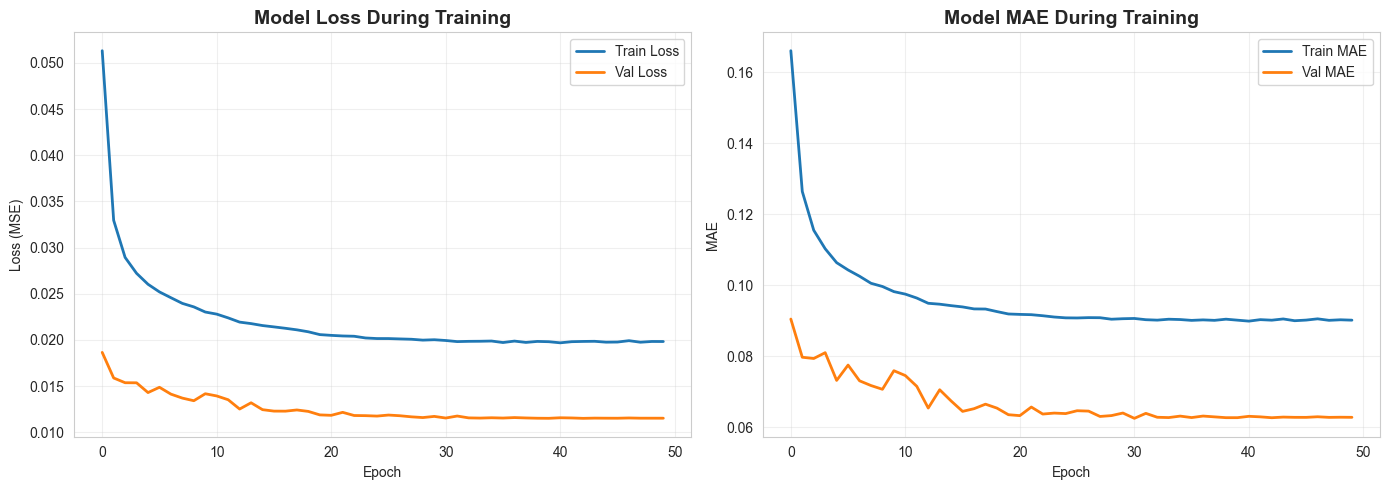

In [16]:
# Plot training history
plt.figure(figsize=(14, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
plt.title('Model Loss During Training', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)

# MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE', linewidth=2)
plt.plot(history.history['val_mae'], label='Val MAE', linewidth=2)
plt.title('Model MAE During Training', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(reports_dir / 'lstm_training_history.png', dpi=100, bbox_inches='tight')
plt.show()
plt.close()


## 11. Model Evaluation


In [18]:
# Generate predictions and evaluate
print("Generating predictions...")

# Predict
y_pred_scaled = model.predict(X_test_scaled, batch_size=BATCH_SIZE, verbose=1)

# Inverse transform to original scale
y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()
y_test_actual = scaler_y.inverse_transform(y_test_scaled).flatten()

# Clean up invalid values
valid_mask = ~(np.isnan(y_pred) | np.isinf(y_pred) | np.isnan(y_test_actual) | np.isinf(y_test_actual) | (y_test_actual == 0))
y_true_clean = y_test_actual[valid_mask]
y_pred_clean = y_pred[valid_mask]

print(f"Valid samples: {len(y_true_clean):,} / {len(y_test_actual):,}")

# Calculate metrics
mae = mean_absolute_error(y_true_clean, y_pred_clean)
rmse = np.sqrt(mean_squared_error(y_true_clean, y_pred_clean))
mape = np.mean(np.abs((y_true_clean - y_pred_clean) / y_true_clean)) * 100
r2 = r2_score(y_true_clean, y_pred_clean)

print("\n" + "="*50)
print("LSTM MODEL RESULTS")
print("="*50)
print(f"MAE:   ${mae:,.2f}")
print(f"RMSE:  ${rmse:,.2f}")
print(f"MAPE:  {mape:.2f}%")
print(f"R²:    {r2:.4f}")
print("="*50)

lstm_metrics = {'Model': 'LSTM', 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R²': r2}


Generating predictions...
55/55 [==============================] - 1s 996us/step
Valid samples: 2,909 / 3,500

LSTM MODEL RESULTS
MAE:   $1,433.80
RMSE:  $1,858.52
MAPE:  11.50%
R²:    0.7827


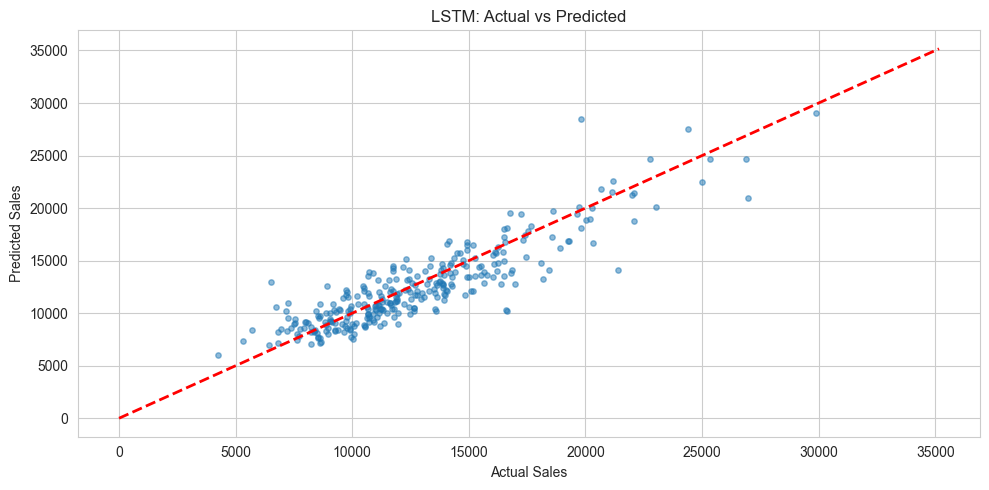

In [20]:
# Quick visualization: Actual vs Predicted
plt.figure(figsize=(10, 5))
sample = np.random.choice(len(y_true_clean), min(300, len(y_true_clean)), replace=False)
plt.scatter(y_true_clean[sample], y_pred_clean[sample], alpha=0.5, s=15)
plt.plot([0, y_true_clean.max()], [0, y_true_clean.max()], 'r--', lw=2)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('LSTM: Actual vs Predicted')
plt.tight_layout()
plt.show()


In [21]:
def calculate_mape(y_true, y_pred):
    """Calculate Mean Absolute Percentage Error"""
    mask = y_true != 0  # Avoid division by zero
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def calculate_metrics(y_true, y_pred, model_name="LSTM"):
    """Calculate all regression metrics with NaN handling"""
    # Flatten arrays if needed
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    
    # Check for NaN or Inf values
    nan_mask = np.isnan(y_true) | np.isnan(y_pred) | np.isinf(y_true) | np.isinf(y_pred)
    nan_count = nan_mask.sum()
    
    if nan_count > 0:
        print(f"⚠ WARNING: Removing {nan_count} NaN/Inf values before calculating metrics")
        print(f"   Original size: {len(y_true)}, Valid size: {len(y_true) - nan_count}")
        logging.warning(f"Removing {nan_count} NaN/Inf values from {len(y_true)} total predictions")
        
        # Filter out NaN/Inf values
        y_true_clean = y_true[~nan_mask]
        y_pred_clean = y_pred[~nan_mask]
        
        if len(y_true_clean) == 0:
            print("\n" + "="*60)
            print(" ERROR: All predictions are NaN or Inf!")
            print("="*60)
            print("The model failed to produce valid predictions.")
            print("\nPlease check the diagnostics above for details.")
            print("\nCommon causes and solutions:")
            print("1. Model weights contain NaN/Inf → Retrain the model")
            print("2. Input data contains NaN/Inf → Clean the data")
            print("3. Training failed (NaN losses) → Check training data quality")
            print("4. Scaling issues → Verify scalers are fitted correctly")
            print("="*60)
            raise ValueError(
                "All predictions are NaN or Inf! Cannot calculate metrics. "
                "See diagnostics above for details. The model likely failed during training "
                "or the input data contains invalid values."
            )
    else:
        y_true_clean = y_true
        y_pred_clean = y_pred
    
    # Calculate metrics on clean data
    mae = mean_absolute_error(y_true_clean, y_pred_clean)
    rmse = np.sqrt(mean_squared_error(y_true_clean, y_pred_clean))
    mape = calculate_mape(y_true_clean, y_pred_clean)
    r2 = r2_score(y_true_clean, y_pred_clean)
    
    # RMSE as percentage of mean
    mean_sales = np.mean(y_true_clean)
    rmse_pct = (rmse / mean_sales) * 100 if mean_sales != 0 else np.nan
    
    metrics = {
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'RMSE%': rmse_pct,
        'MAPE': mape,
        'R²': r2,
        'Valid_Samples': len(y_true_clean),
        'Total_Samples': len(y_true),
        'NaN_Count': nan_count
    }
    
    return metrics

# Calculate metrics
lstm_metrics = calculate_metrics(y_test_actual, y_pred, "LSTM")

# Display metrics
print("\n" + "="*60)
print("LSTM MODEL PERFORMANCE METRICS")
print("="*60)
for metric, value in lstm_metrics.items():
    if metric == 'Model':
        continue
    if metric in ['Valid_Samples', 'Total_Samples', 'NaN_Count']:
        print(f"{metric:12s}: {value:10d}")
    elif isinstance(value, float) and (np.isnan(value) or np.isinf(value)):
        print(f"{metric:12s}: {'N/A':>10s}")
    else:
        print(f"{metric:12s}: {value:10.4f}")
print("="*60)

# Log metrics
logging.info(f"LSTM Metrics: {lstm_metrics}")


2025-12-08 14:19:52,326 - INFO - LSTM Metrics: {'Model': 'LSTM', 'MAE': 1628.1876220703125, 'RMSE': 2756.710902506826, 'RMSE%': 25.885162454110805, 'MAPE': 11.498481035232544, 'R²': 0.7903741002082825, 'Valid_Samples': 3500, 'Total_Samples': 3500, 'NaN_Count': 0}



LSTM MODEL PERFORMANCE METRICS
MAE         :  1628.1876
RMSE        :  2756.7109
RMSE%       :    25.8852
MAPE        :    11.4985
R²          :     0.7904
Valid_Samples:       3500
Total_Samples:       3500
NaN_Count   :          0


## 12. Visualizations


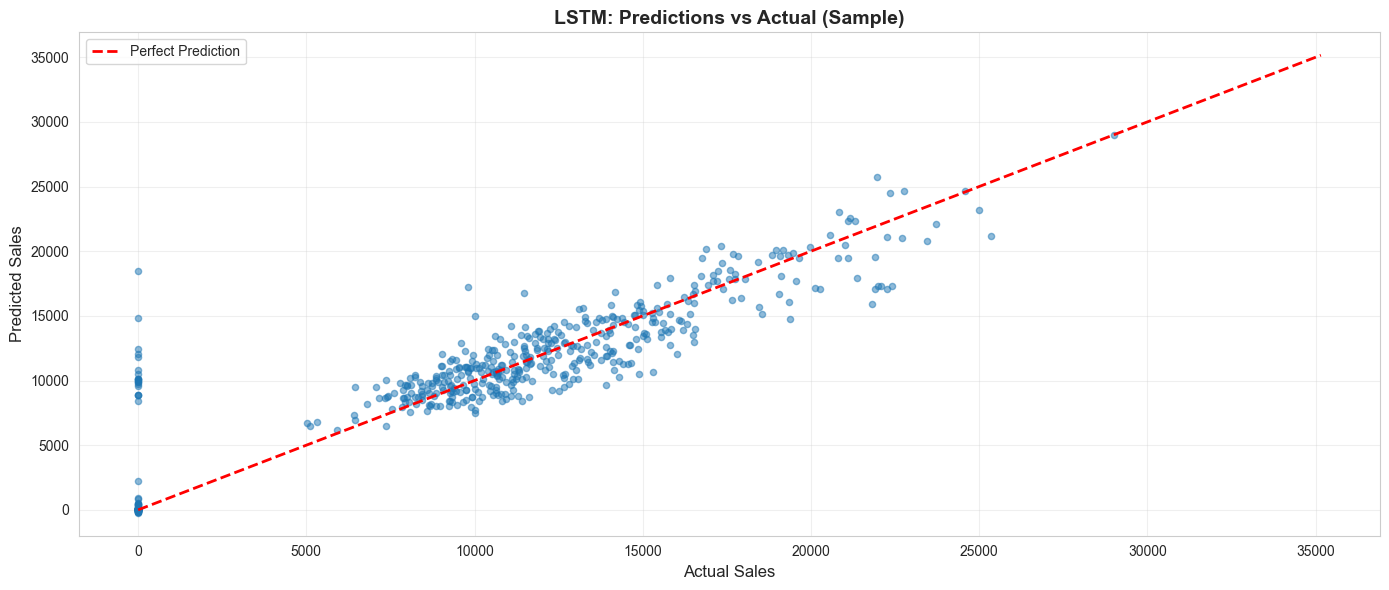

In [22]:
# 1. Predictions vs Actual (sample for visualization)
sample_size = min(500, len(y_test_actual))
sample_indices = np.random.choice(len(y_test_actual), sample_size, replace=False)

plt.figure(figsize=(14, 6))
plt.scatter(y_test_actual[sample_indices], y_pred[sample_indices], alpha=0.5, s=20)
plt.plot([y_test_actual.min(), y_test_actual.max()], 
         [y_test_actual.min(), y_test_actual.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Sales', fontsize=12)
plt.ylabel('Predicted Sales', fontsize=12)
plt.title('LSTM: Predictions vs Actual (Sample)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(reports_dir / 'lstm_predictions_vs_actual.png', dpi=100, bbox_inches='tight')
plt.show()
plt.close()


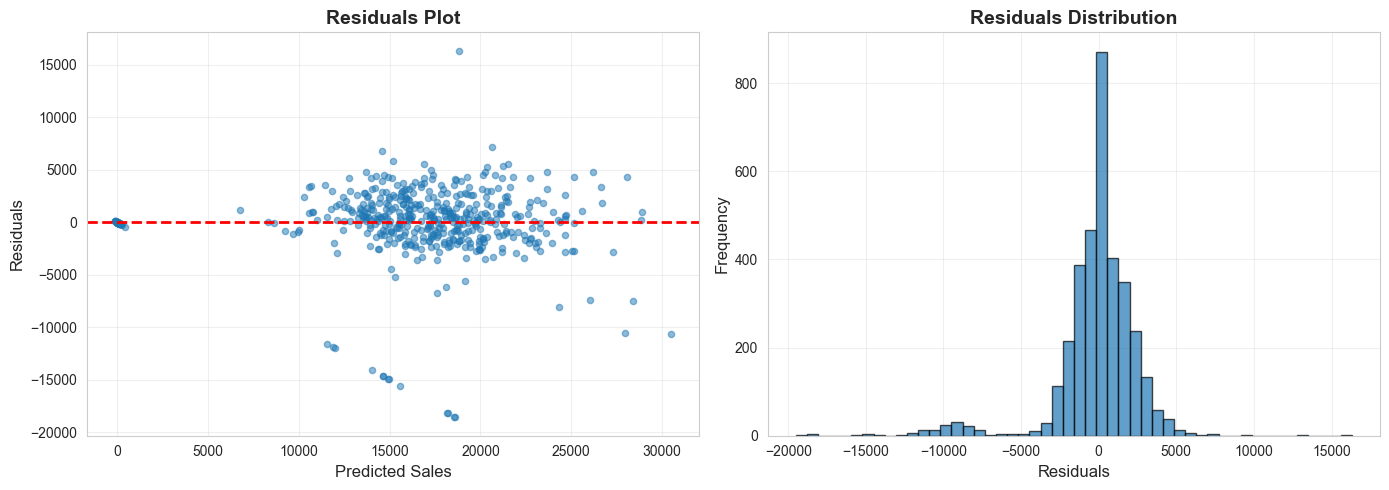

In [51]:
# 2. Residuals plot
residuals = y_test_actual.flatten() - y_pred.flatten()

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_pred.flatten()[:sample_size], residuals[:sample_size], alpha=0.5, s=20)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted Sales', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Residuals Plot', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(residuals, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Residuals', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Residuals Distribution', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(reports_dir / 'lstm_residuals_analysis.png', dpi=100, bbox_inches='tight')
plt.show()
plt.close()


## 13. Summary & Next Steps

The LSTM model was trained and evaluated using a 2-layer architecture with 32 and 16 units and early stopping to prevent overfitting. It is memory-efficient, trains quickly on a local machine, and is lightweight for deployment. Generated files include model checkpoints, scalers, and reports for training, predictions, and residual analysis.

Next steps are to compare LSTM with ML models, trying different hyperparameters, explore ensembles, and prepare the model for production. Training is completed
